In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

#DERGEE 1 POLYNOMIAL

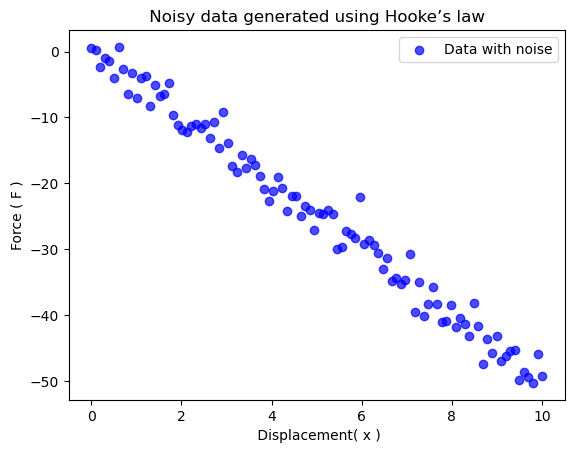

 In - sample error ( E_in ):3.822521410308932
 Out - of - sample error ( E_out ):4.5651073768440655


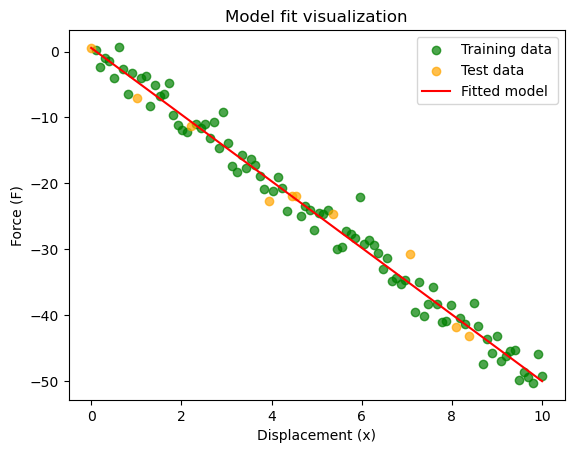

In [ ]:
#Parameters
k = 5
sigma = 2
N = 100 # Number of data points
# Generate data
x = np.linspace (0 , 10 , N )
noise = np.random.normal (0 , sigma , N )
F = -k * x + noise
# Plot data
plt.scatter(x ,F, label = "Data with noise", color = "blue", alpha =0.7)
plt.xlabel(" Displacement( x )")
plt.ylabel("Force ( F )")
plt.title(" Noisy data generated using Hooke’s law ")
plt.legend()
plt.show()


# Split the data
x_train,x_test,F_train,F_test = train_test_split(x , F , test_size =0.1 , random_state =42)
"""
· x(Features / Características): Son los datos de entrada o variables independientes. 
  Por ejemplo, si estás prediciendo el precio de casas, x contendría el tamaño, número de habitaciones, ubicación, etc.
  X_TRAIN (DATOS DE APRENDIZAJE) // X_TEST (DATOS DE EXAMEN)

· F (Target / Objetivo): Son las etiquetas o la variable dependiente (lo que quieres predecir). LAS RESPUESTAS AL EXAMEN
F_TRAIN (RESPUESTAS EXAMEN PRUEBA) // F_TEST (RESPUESTAS EXAMEN REAL)

· test_size=0.1: Define el tamaño del conjunto de prueba. 
  0.1 significa que el 10% de los datos se separarán para ser usados como prueba (test).
  Por consecuencia, el 90% restante se usará para el entrenamiento (train)

· Las computadoras no son realmente aleatorias; usan fórmulas matemáticas para simular el azar. 
  Estas fórmulas necesitan un número inicial para empezar a calcular, llamado semilla (seed).

· Todo esot lo hacemos para evitar el Overfitting (Sobreajuste).
  Si entrenas y pruebas tu modelo con los mismos datos, el modelo simplemente "memorizará" las respuestas.
  Al guardar un 10% de datos ocultos (x_test, F_test), puedes verificar si tu modelo realmente aprendió a 
  generalizar o si solo memorizó.
"""


# Linear model (ZONA DE ENTRENE)
poly = PolynomialFeatures(degree =1) #Establecemos un polinomio de grado 1, Su utilidad principal aquí es que añade automáticamente una columna de "unos" 
#(1) que sirve para calcular el "intercepto" (la b en la ecuacióny=mx+b)

x_train_poly = poly.fit_transform(x_train.reshape( -1 , 1)) #Reshape converts our data from row --> colum //     
#Fit (Aprender): La máquina poly mira los datos para ver cómo son. Transform (Transformar): 
# Aplica el cambio (añade la columna de unos y ajusta el formato). El resultado se guarda en x_train_poly.

x_test_poly = poly.transform(x_test.reshape( -1 , 1))
# NO USAMOS FIT. Si usamos fit aquí, la máquina aprendería de los datos de prueba, y eso sería "hacer trampa". Solo aplicamos la transformación que aprendimos en el paso anterior.

model = LinearRegression()
model.fit(x_train_poly, F_train)

"""
Le damos al modelo dos cosas:

    Las preguntas del examen de práctica (x_train_poly).

    Las respuestas correctas de esas preguntas (F_train).

    El modelo busca patrones matemáticos para relacionar la pregunta con la respuesta. 
    Encuentra la "línea" que mejor conecta los puntos.
"""



# Predictions (EL EXAMEN)
# Ahora le quitamos las respuestas correctas y le decimos al modelo: "Toma estos datos, usa lo que aprendiste y dime qué resultado crees que sale".
F_train_pred = model.predict(x_train_poly) 
#El modelo responde las mismas preguntas con las que estudió. (Esto nos dice si tiene buena memoria).
F_test_pred = model.predict(x_test_poly)
#El modelo responde preguntas nuevas que nunca ha visto. (Esto nos dice si realmente entendió la lógica).


# Calculate errors ("qué tan lejos estuvo la predicción de la realidad")
E_in = mean_squared_error (F_train, F_train_pred ) #Error training set
E_out = mean_squared_error (F_test, F_test_pred ) # Error test set
print(f" In - sample error ( E_in ):{ E_in }")
print(f" Out - of - sample error ( E_out ):{ E_out }")
#Compara lo que dijo el modelo (..._pred) contra lo que realmente pasó (F_train o F_test).

plt.scatter(x_train, F_train , label = "Training data",color ="green",alpha =0.7)
plt.scatter(x_test, F_test , label = "Test data" , color = "orange",alpha =0.7)

#Los puntos (Scatter): Representan la REALIDAD. Son los datos x_train/F_train (lo que ya pasó) y 
# x_test/F_test (lo que pasó pero ocultamos). Los pintamos para tener una referencia de "la verdad".

plt.plot(x, model.predict( poly.transform(x.reshape ( -1 , 1) )),label = "Fitted model", color = "red")

#La línea (Plot): Representa al MODELO (PREDICCIONES). Esa línea roja se dibuja conectando todos los puntos predichos (F_pred).
#Si pintáramos F_test_pred como puntos, caerían exactamente encima de la línea roja. 
#Por eso, en lugar de pintar puntos de predicción, pintamos la "línea de tendencia" completa.

plt.xlabel("Displacement (x)")
plt.ylabel("Force (F)")
plt.title("Model fit visualization")
plt.legend()
plt.show()

#DERGEE 2 POLYNOMIAL

SE DA EL OVERFITTING EN CIERTOS CASOS COMO CUANDO EL MODELO ES DEMASIADO COMPLEJO Y LA MACHINE NO TIENE LA CAPACIDAD DE ESTUDIAR LO ENTONCES DIRECTAMENTE COPIA LOS RESULTADOS DE LOS DATOS QUE HA ESTUDIADO.

NUEVO TERMINO -C*X**3

Antes (Train/Test simple): Tenías 100 preguntas. Usabas 90 para estudiar (Train) y 10 para el examen final (Test). Problema: ¿Qué pasa si esas 10 preguntas del examen final eran súper fáciles o súper difíciles por pura casualidad? Tu evaluación del estudiante no sería precisa.

Ahora (Cross-Validation con k=5 "pliegues"):

    Coges tus 90 preguntas de estudio y las divides en 5 bloques de 18 preguntas.

    El estudiante estudia 4 bloques y hace un "mini-examen" con el bloque restante.

    Repites esto 5 veces, rotando el bloque que se usa para el mini-examen.

    Al final, sacas la nota media de esos 5 mini-exámenes.

--- RESULTADOS DE VALIDACIÓN CRUZADA (Estudiando) ---
Modelo Grado  1 | Error Medio (CV): 68.65
Modelo Grado  2 | Error Medio (CV): 17.05
Modelo Grado  3 | Error Medio (CV): 13.71
Modelo Grado  4 | Error Medio (CV): 13.68
Modelo Grado  5 | Error Medio (CV): 13.88
Modelo Grado  8 | Error Medio (CV): 13.69
Modelo Grado 12 | Error Medio (CV): 14.45

¡El ganador es el Modelo de Grado 4!
Error en el Examen Final (E_out) del ganador: 22.28


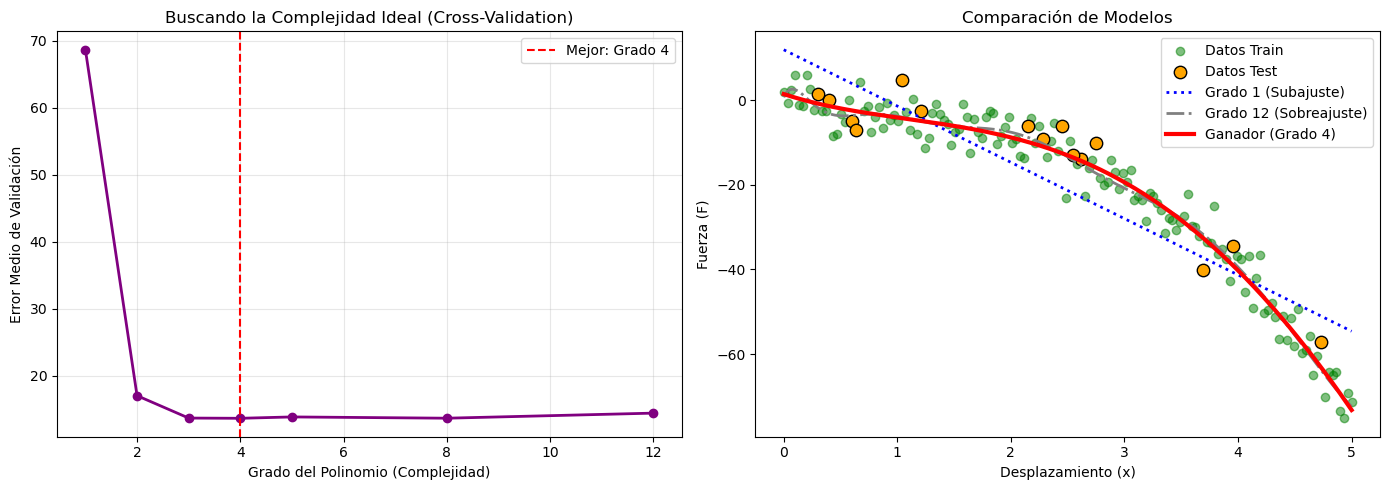

In [ ]:
# ==========================================
# 1. GENERAR DATOS (Muelle No Lineal)
# ==========================================
np.random.seed(42) # Para que siempre salga el mismo ruido
N = 150
x = np.linspace(0, 5, N) # Desplazamiento de 0 a 5
k = 2  # Rigidez lineal
c = 0.5   # Rigidez no lineal (el término cúbico)
sigma = 4.0 # Ruido

# Nueva ley física: F = -kx - cx^3 + ruido
noise = np.random.normal(0, sigma, N)

F = -k * x - c * x**3 + noise


# Dividimos en Train (90%) y Test (Examen final intocable - 10%)
x_train, x_test, F_train, F_test = train_test_split(x, F, test_size=0.1, random_state=42)



# ==========================================
# 2. EXPLORAR MODELOS CON CROSS-VALIDATION
# ==========================================
# Vamos a probar polinomios desde el grado 1 (línea recta) hasta el 12 (muy complejo)
grados_a_probar = [1, 2, 3, 4, 5, 8, 12]
errores_cv = [] # Aquí guardaremos la "nota media" de cada modelo

print("--- RESULTADOS DE VALIDACIÓN CRUZADA (Estudiando) ---")
for grado in grados_a_probar:
    # Creamos el modelo (con StandardScaler para evitar inestabilidad numérica)
    modelo = make_pipeline(PolynomialFeatures(degree=grado), StandardScaler(), LinearRegression())
    
    # CROSS-VALIDATION (cv=5 significa 5 mini-exámenes)
    # scoring='neg_mean_squared_error' devuelve el error en negativo, le damos la vuelta con un menos (-)
    scores = -cross_val_score(modelo, x_train.reshape(-1, 1), F_train, cv=5, scoring='neg_mean_squared_error')
    
    error_medio = scores.mean()
    errores_cv.append(error_medio)
    print(f"Modelo Grado {grado:2d} | Error Medio (CV): {error_medio:.2f}")



# ==========================================
# 3. ELEGIR EL MEJOR MODELO Y HACER EL EXAMEN FINAL
# ==========================================
# Buscamos qué grado tuvo el error más bajo
mejor_indice = np.argmin(errores_cv)
mejor_grado = grados_a_probar[mejor_indice]
print(f"\n¡El ganador es el Modelo de Grado {mejor_grado}!")

# Ahora entrenamos al ganador con TODOS los datos de estudio
modelo_ganador = make_pipeline(PolynomialFeatures(degree=mejor_grado), StandardScaler(), LinearRegression())
modelo_ganador.fit(x_train.reshape(-1, 1), F_train)

# Y le hacemos el Examen Final (Test)
F_test_pred = modelo_ganador.predict(x_test.reshape(-1, 1))
E_out_final = mean_squared_error(F_test, F_test_pred)
print(f"Error en el Examen Final (E_out) del ganador: {E_out_final:.2f}")



# ==========================================
# 4. VISUALIZACIÓN
# ==========================================
plt.figure(figsize=(14, 5))

# Gráfico 1: La curva de Cross-Validation (En busca del punto dulce)
plt.subplot(1, 2, 1)
plt.plot(grados_a_probar, errores_cv, marker='o', color='purple', linewidth=2)
plt.axvline(x=mejor_grado, color='red', linestyle='--', label=f'Mejor: Grado {mejor_grado}')
plt.title("Buscando la Complejidad Ideal (Cross-Validation)")
plt.xlabel("Grado del Polinomio (Complejidad)")
plt.ylabel("Error Medio de Validación")
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico 2: Visualización de los modelos sobre los datos
plt.subplot(1, 2, 2)
plt.scatter(x_train, F_train, color='green', alpha=0.5, label='Datos Train')
plt.scatter(x_test, F_test, color='orange', s=80, edgecolor='black', label='Datos Test')

x_plot = np.linspace(0, 5, 200).reshape(-1, 1)

# Pintamos el modelo perdedor (Grado 1 - Underfitting)
modelo_malo = make_pipeline(PolynomialFeatures(degree=1), StandardScaler(), LinearRegression())
modelo_malo.fit(x_train.reshape(-1, 1), F_train)
plt.plot(x_plot, modelo_malo.predict(x_plot), color='blue', linestyle=':', linewidth=2, label='Grado 1 (Subajuste)')

# Pintamos el modelo sobreajustado (Grado 12 - Overfitting)
modelo_loco = make_pipeline(PolynomialFeatures(degree=12), StandardScaler(), LinearRegression())
modelo_loco.fit(x_train.reshape(-1, 1), F_train)
plt.plot(x_plot, modelo_loco.predict(x_plot), color='gray', linestyle='-.', linewidth=2, label='Grado 12 (Sobreajuste)')

# Pintamos el ganador
plt.plot(x_plot, modelo_ganador.predict(x_plot), color='red', linewidth=3, label=f'Ganador (Grado {mejor_grado})')

plt.title("Comparación de Modelos")
plt.xlabel("Desplazamiento (x)")
plt.ylabel("Fuerza (F)")
plt.legend()

plt.tight_layout()
plt.show()

------------ RESULTADOS ------------
 Grado del polinomio: 15
 In-sample error (E_in): 4.2236  <-- Será bajo (se aprendió el ruido)
 Out-of-sample error (E_out): 6.3924 <-- Será ALTÍSIMO (falló el examen)
------------------------------------


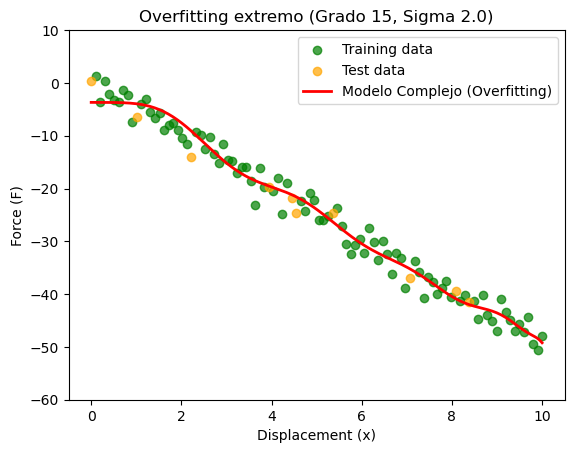

In [ ]:
# --- CAMBIO 1: AUMENTAR EL RUIDO ---
k = 5
sigma = 2.0  # <--- ANTES 0.1. Aumentamos el ruido para despistar al modelo
N = 100 

# Generate data
x = np.linspace(0, 10, N)
noise = np.random.normal(0, sigma, N)
F = -k * x + noise

# Split the data
x_train, x_test, F_train, F_test = train_test_split(x, F, test_size=0.1, random_state=42)

# --- CAMBIO 2: AUMENTAR LA COMPLEJIDAD ---
# Linear model (ZONA DE ENTRENE)
# Cambiamos degree=1 por degree=15. 
# Esto le da al modelo "libertad" para hacer curvas extremas.
poly = PolynomialFeatures(degree=15) 

x_train_poly = poly.fit_transform(x_train.reshape(-1, 1))
x_test_poly = poly.transform(x_test.reshape(-1, 1))

model = LinearRegression()
model.fit(x_train_poly, F_train)

# Predictions (EL EXAMEN)
F_train_pred = model.predict(x_train_poly)
F_test_pred = model.predict(x_test_poly)

# Calculate errors
E_in = mean_squared_error(F_train, F_train_pred)
E_out = mean_squared_error(F_test, F_test_pred)

print(f"------------ RESULTADOS ------------")
print(f" Grado del polinomio: 15")
print(f" In-sample error (E_in): {E_in:.4f}  <-- Será bajo (se aprendió el ruido)")
print(f" Out-of-sample error (E_out): {E_out:.4f} <-- Será ALTÍSIMO (falló el examen)")
print(f"------------------------------------")

# Plotting
plt.scatter(x_train, F_train, label="Training data", color="green", alpha=0.7)
plt.scatter(x_test, F_test, label="Test data", color="orange", alpha=0.7)

# Para dibujar la línea loca del modelo correctamente, necesitamos muchos puntos ordenados
x_plot = np.linspace(0, 10, 200) 
plt.plot(x_plot, model.predict(poly.transform(x_plot.reshape(-1, 1))), 
         label="Modelo Complejo (Overfitting)", color="red", linewidth=2)

plt.xlabel("Displacement (x)")
plt.ylabel("Force (F)")
plt.title(f"Overfitting extremo (Grado 15, Sigma {sigma})")
plt.legend()
plt.ylim(-60, 10) # Limitamos la vista vertical porque la línea se saldrá de la gráfica
plt.show()